In [1]:
"""Code to plot RL training in thinking experiments."""
import sys
import argparse
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter
from statsmodels.stats.proportion import proportion_confint

sns.set_palette("colorblind")

In [27]:
baseline_directory = "EXPS/baseline"
baseline_directory = ""
results_directory = "EXPS/debug_results-d_model_16-n_heads_1"
results_directory = "EXPS/debug_results-d_model_16-n_heads_1-n_thought_states_10"
results_directory = "EXPS/frozen_lake-ppo"
results_directory = "EXPS/frozen_lake-ppo-longer"
results_directory = "EXPS/frozen_lake-ppo-iterations_1000"
results_directory = "EXPS/frozen_lake-v4-ppo-iterations_2500"
results_directory = "EXPS/frozen_lake-v4-ppo-iterations_2500-ent_coef_0.02"
# results_directory = "EXPS/debug_results-d_model_16-n_heads_4"
# results_directory = "EXPS/debug_results-d_model_32-n_heads_4"
# results_directory = "EXPS/debug_results-d_model_64-n_heads_1"
plot_actions = False


# Optional: set a set of labels to use for plot
base_to_label = {
    'pretrained-think': 'Pretrained-Think',
    'pretrained-nothink': 'Pretrained-NoThink',
    'scratch-think': 'Scratch-Think',
    'scratch-nothink': 'Scratch-NoThink'
}
# base_to_label = {}

data_list = []

for curr_dir in [results_directory, baseline_directory]:
    if curr_dir.endswith(baseline_directory) and not os.path.isdir(curr_dir):
        continue
    for filename in os.listdir(curr_dir):

        if ".npy" not in filename:
            continue

        if plot_actions and "-thinkactions.npy" not in filename:
            continue

        if not plot_actions and "-thinkactions.npy" in filename:
            continue

        base = "_".join(filename.split("_")[:-1])
        seed = re.findall(r"-?\d+", filename)[-1]

        if base in base_to_label:
            base = base_to_label[base]

        x = np.load(os.path.join(curr_dir, filename))

        for t, val in enumerate(x):
            data_list.append({"timepoint": t, "value": val, "series": base, "run": seed})


In [28]:
# Create DataFrame
df_all = pd.DataFrame(data_list)

df_all["series"] = df_all["series"].str.replace('test_thought_env-', '')

# df_all = df_all[~df_all["series"].str.contains("n_thought_states_10")]

In [29]:
df_all.value

0        0.00
1        0.00
2        0.00
3        0.00
4        0.00
         ... 
52495    1.00
52496    0.94
52497    1.00
52498    0.98
52499    0.96
Name: value, Length: 52500, dtype: float64

In [30]:
stats_df

,series,timepoint,mean,count,std,success_rate,ci,lower,upper,success_rate_smooth,lower_smooth,upper_smooth
0,n_thought_states_1-n_thought_acts_1,0,0.000,4,0.000000,0.000,0.000000,0.000000,0.000000,0.000128,-0.000122,0.000377
1,n_thought_states_1-n_thought_acts_1,1,0.000,4,0.000000,0.000,0.000000,0.000000,0.000000,0.000386,-0.000370,0.001142
2,n_thought_states_1-n_thought_acts_1,2,0.000,4,0.000000,0.000,0.000000,0.000000,0.000000,0.000566,-0.000544,0.001677
3,n_thought_states_1-n_thought_acts_1,3,0.000,4,0.000000,0.000,0.000000,0.000000,0.000000,0.000678,-0.000651,0.002006
4,n_thought_states_1-n_thought_acts_1,4,0.005,4,0.010000,0.005,0.009800,-0.004800,0.014800,0.000729,-0.000699,0.002156
...,...,...,...,...,...,...,...,...,...,...,...,...
12495,no_thought_acts,2495,0.216,5,0.057271,0.216,0.050200,0.165800,0.266200,0.217691,0.171802,0.263580
12496,no_thought_acts,2496,0.228,5,0.033466,0.228,0.029335,0.198665,0.257335,0.216445,0.172336,0.260553
12497,no_thought_acts,2497,0.200,5,0.024495,0.200,0.021471,0.178529,0.221471,0.214650,0.172611,0.256690
12498,no_thought_acts,2498,0.212,5,0.038987,0.212,0.034174,0.177826,0.246174,0.212229,0.172559,0.251899


In [31]:
# -----------------------------
# 1. Aggregate: successes + trials
# -----------------------------
# stats_df = (
#     df_all.groupby(["series", "timepoint"])
#     .agg(
#         success_rate=("value", "mean"),  # assumes value is 0/1 per episode
#         n=("value", "count"),
#     )
#     .reset_index()
# )

# # convert rate -> successes
# stats_df["successes"] = stats_df["success_rate"] * stats_df["n"]

# -----------------------------
# 2. Binomial CI (Wilson)
# -----------------------------
# ci_low, ci_high = proportion_confint(
#     count=stats_df["successes"],
#     nobs=stats_df["n"],
#     alpha=0.05,
#     method="wilson",
# )

# stats_df["lower"] = ci_low
# stats_df["upper"] = ci_high

stats_df = (
    df_all.groupby(["series", "timepoint"])["value"]
    .agg(["mean", "count", "std"])
    .reset_index()
)

stats_df["success_rate"] = stats_df["mean"]
stats_df["ci"] = 1.96 * stats_df["std"] / np.sqrt(stats_df["count"])
stats_df["lower"] = stats_df["mean"] - stats_df["ci"]
stats_df["upper"] = stats_df["mean"] + stats_df["ci"]

# -----------------------------
# 3. Savitzky–Golay smoothing helper
# -----------------------------
def smooth_series(x, window=21, poly=3):
    x = np.asarray(x)

    # adapt window to length
    w = min(window, len(x) if len(x) % 2 == 1 else len(x) - 1)
    w = max(w, poly + 2 + (poly + 2) % 2)  # ensure valid odd window

    return savgol_filter(x, window_length=w, polyorder=poly)

# sort for stability
stats_df = stats_df.sort_values(["series", "timepoint"])

for col in ["success_rate", "lower", "upper"]:
    stats_df[f"{col}_smooth"] = (
        stats_df.groupby("series")[col]
        .transform(lambda x: smooth_series(x, window=21, poly=3))
    )

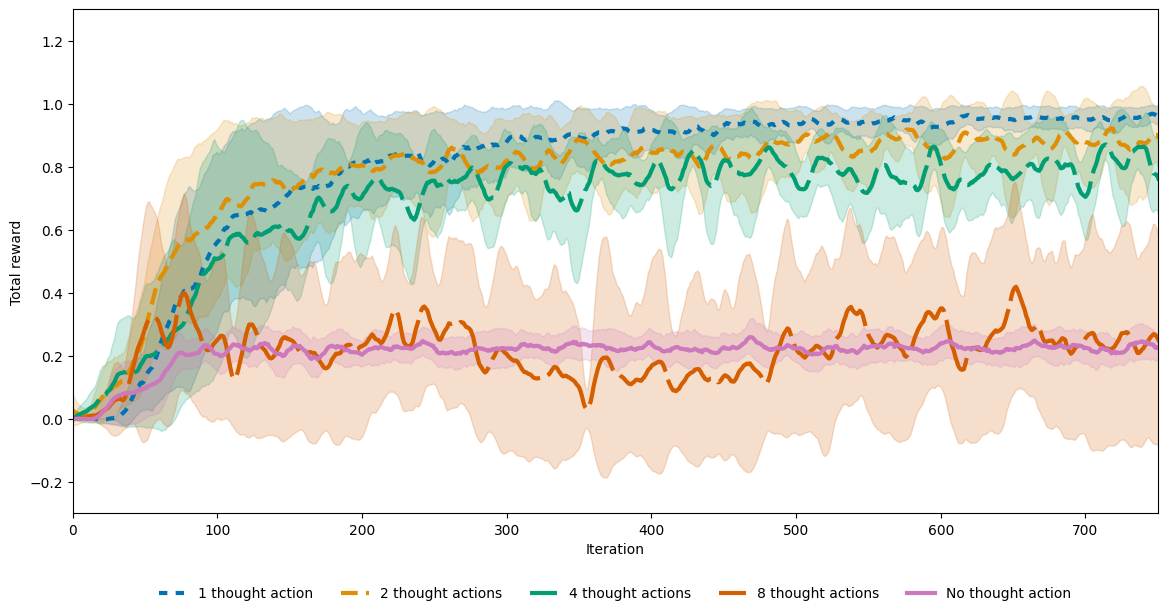

In [42]:
fig, ax = plt.subplots(figsize=(14, 8))
# Mean curves
# sns.lineplot(
#     data=df_all,
#     x="timepoint",
#     y="value",
#     hue="series",
#     style="series",
#     estimator="mean",
#     lw=1,
#     errorbar="ci",
#     ax=ax,
#     alpha=0.3,
# )

# sns.lineplot(
#     data=df_all,
#     x="timepoint",
#     y="value",
#     hue="series",
#     style="series",
#     units="run",
#     lw=1,
#     estimator=None,
#     alpha=0.7,
# )

linestyle_map = {
    "no_thought_acts": "-",
    "n_thought_states_1-n_thought_acts_1": (0, (2, 2)),   # short dashes
    "n_thought_states_1-n_thought_acts_2": (0, (4, 2)),   # medium-short
    "n_thought_states_1-n_thought_acts_4": (0, (8, 2)),   # medium-long
    "n_thought_states_1-n_thought_acts_8": (0, (16, 2)),  # long dashes
}
label_map = {
    "no_thought_acts": "No thought action",
    "n_thought_states_1-n_thought_acts_1": "1 thought action",
    "n_thought_states_1-n_thought_acts_2": "2 thought actions",
    "n_thought_states_1-n_thought_acts_4": "4 thought actions",
    "n_thought_states_1-n_thought_acts_8": "8 thought actions",
}


palette = sns.color_palette(n_colors=stats_df["series"].nunique())
for color, (series, group) in zip(
    palette,
    stats_df.groupby("series", sort=False),
):
    group = group.sort_values("timepoint")

    ax.plot(
        group["timepoint"],
        group["success_rate_smooth"],
        lw=3,
        color=color,
        label=label_map[series],
        linestyle=linestyle_map[series],
    )

    ax.fill_between(
        group["timepoint"],
        group["lower_smooth"],
        group["upper_smooth"],
        color=color,
        alpha=0.2,
    )

# Get only the series legend entries
# handles, labels = ax.get_legend_handles_labels()

# Remove duplicates introduced by style=
# series_handles = handles[:df_all["series"].nunique()]
# series_labels = labels[:df_all["series"].nunique()]

# Add custom linestyle explanation
# series_handles += [
#     Line2D([0], [0], color="black", lw=3, linestyle="-"),
#     Line2D([0], [0], color="black", lw=3, linestyle="--"),
# ]
# series_labels += ["Thinking", "No Thinking"]

# ax.legend(
#     series_handles,
#     series_labels,
#     loc="upper center",
#     bbox_to_anchor=(0.5, -0.12),
#     ncol=3,
#     fontsize=12,
#     frameon=False,
#     title=None,
# )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=False,
)

ax.set_ylabel("Total reward")
ax.set_xlabel("Iteration")
ax.set_xlim(0, 750)
ax.set_ylim(-0.3, 1.3)

plt.subplots_adjust(bottom=0.25)
plt.show()